In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist
import os

In [3]:
data_path = "../Dataset/UCPMP/UCPPM_Dataset.csv"
# filename = "experiment_data.csv"
# filepath = os.path.join("..", filename)
# df = pd.read_csv(data_path)
# df

### Preprocessing

In [4]:
import pandas as pd
import ast
import numpy as np
class Preprocessing:
    def __init__(self, data_path):
        """Initialize analysis with data path"""
        self.df = pd.read_csv(data_path)
        print("\nDataset loaded successfully.")
        print(f"Initial number of records: {len(self.df)}")
        self.preprocess_data()

    def getPreprocessedData(self):
        return self.df

    def preprocess_data(self):
        print("Preprocessing start")
        self.df['path'] = self.df.apply(lambda x: ast.literal_eval(x.path), axis=1)
        self.df['time_diff_ms'] = self.df.apply(lambda x: ast.literal_eval(x.time_diff_ms), axis=1)
        self.df['distances'] = self.df.apply(lambda x: self.distance_from_target(x.target_point_x, x.target_point_y, x.path), axis=1)
        self.df['rmsd'] = self.df.apply(lambda x: self.calculate_path_rmsd(x.path, (x.start_point_x, x.start_point_y),
                                                            (x.target_point_x, x.target_point_y)), axis=1)
        print("Preprocessing end")

    def distance_from_target(self, target_x, target_y, path_array):
        path = np.array(path_array)
        target = np.array((target_x, target_y))
        distances = np.sqrt(np.sum((target - path) ** 2, axis=1))
        return distances

    def calculate_path_rmsd(self, path_array, start_point, target_point):
        """
        Calculate Root Mean Square Deviation of a path from the straight line
        between start and target points.

        Parameters:
        path_array: numpy array of shape (n, 2) containing path coordinates
        start_point: tuple or array (x, y) of start position
        target_point: tuple or array (x, y) of target position

        Returns:
        float: RMSD value representing deviation from straight line
        """
        # Convert inputs to numpy arrays if they aren't already
        path = np.array(path_array)
        start = np.array(start_point)
        target = np.array(target_point)

        def point_to_line_distance(point, line_start, line_end):
            """
            Calculate the perpendicular distance from a point to a line defined by two points.
            Uses the formula: distance = |ax + by + c| / sqrt(a² + b²)
            where ax + by + c = 0 is the line equation
            """
            # Line equation coefficients: ax + by + c = 0
            a = line_end[1] - line_start[1]  # y2 - y1
            b = line_start[0] - line_end[0]  # x1 - x2
            c = line_end[0] * line_start[1] - line_start[0] * line_end[1]  # x2*y1 - x1*y2

            # Calculate perpendicular distance
            numerator = np.abs(a * point[0] + b * point[1] + c)
            denominator = np.sqrt(a ** 2 + b ** 2)

            return numerator / denominator if denominator != 0 else 0

        # Calculate distances from each path point to the straight line
        distances = np.array([point_to_line_distance(point, start, target)
                              for point in path])

        # Calculate RMSD
        rmsd = np.sqrt(np.mean(distances ** 2))

        return rmsd





In [5]:
import numpy as np
import ast


def normalize_trajectory_3d(trajectory, time_sequence, target_position=np.array([1.0, 0.0])):
    """
    Normalize trajectory spatially while preserving original time.

    Args:
        trajectory: numpy array of shape (num_points, 2) containing x,y coordinates
        time_sequence: numpy array of timestamps in milliseconds for each point
        target_position: desired end position for all trajectories (default: [1,0])

    Returns:
        Normalized 3D trajectory (x, y, time_in_seconds)
    """
    # Convert time from milliseconds to seconds
    time_sequence_seconds = time_sequence / 1000.0

    # Spatial normalization
    start_pos = trajectory[0]
    centered = trajectory - start_pos

    # Get current target position after centering
    current_target = centered[-1]

    # Calculate rotation angle to align with desired target
    current_angle = np.arctan2(current_target[1], current_target[0])
    desired_angle = np.arctan2(target_position[1], target_position[0])
    rotation_angle = desired_angle - current_angle

    # Create rotation matrix
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    rotation_matrix = np.array([[cos_theta, -sin_theta],
                                [sin_theta, cos_theta]])

    # Rotate trajectory
    rotated = np.dot(centered, rotation_matrix.T)

    # Scale to match target length
    current_length = np.linalg.norm(rotated[-1])
    target_length = np.linalg.norm(target_position)
    scale_factor = target_length / current_length if current_length > 0 else 1

    normalized_spatial = rotated * scale_factor

    # Create 3D trajectory with time in seconds
    trajectory_3d = np.column_stack((normalized_spatial, time_sequence_seconds))

    return trajectory_3d


def normalize_trajectory_sequence_3d(path, time_diff_ms, target_position=np.array([1.0, 0.0]), target_length=512):
    """
    Normalize a trajectory into 3D (x, y, time_in_seconds).

    Args:
        path: trajectory coordinates as string or numpy array
        time_diff_ms: time differences in milliseconds
        target_position: desired end position (default: [1,0])
        target_length: desired number of points after resampling (default: 100)

    Returns:
        Normalized 3D trajectory with time in seconds
    """
    # Parse input trajectory
    trajectory = np.array(eval(path) if isinstance(path, str) else path)

    # Parse time sequence
    time_sequence = np.array(eval(time_diff_ms) if isinstance(time_diff_ms, str) else time_diff_ms)

    norm_traj_3d = np.array([])

    if isinstance(trajectory, np.ndarray) and trajectory.size > 0 and not np.all(trajectory == 0):
        # Normalize to 3D with time in seconds
        norm_traj_3d = normalize_trajectory_3d(trajectory, time_sequence, target_position)

        # Optional resampling (only for spatial coordinates)
        if target_length is not None and target_length > 2:
            t = np.linspace(0, 1, target_length)
            t_original = np.linspace(0, 1, len(norm_traj_3d))

            # Resample spatial coordinates
            resampled_spatial = np.vstack([
                np.interp(t, t_original, norm_traj_3d[:, 0]),
                np.interp(t, t_original, norm_traj_3d[:, 1])
            ]).T

            # Resample time to maintain correspondence
            resampled_time = np.interp(t, t_original, norm_traj_3d[:, 2])

            norm_traj_3d = np.column_stack((resampled_spatial, resampled_time))

    return norm_traj_3d


def normalize_trajectory_sequence_3d_directionality(path, time_diff_ms, target_position=np.array([1.0, 0.0]), target_length=512, return_dict=True):
    """Normalize trajectory while preserving and returning original directional information.

    Args:
        path: trajectory coordinates as string or numpy array of shape (N,2) or (N,>=2)
        time_diff_ms: time differences in milliseconds (string or array)
        target_position: canonical end position after rotation/scale (default [1,0])
        target_length: optional resampled length (default 512)
        return_dict: if True returns a dict with metadata; else returns tuple

    Returns:
        dict or tuple containing:
            normalized_trajectory: (L,3) array after centering, rotation, scaling, time (seconds)
            original_target_angle: angle (radians) start->original end before normalization
            rotation_angle: applied rotation (desired_angle - original_target_angle)
            original_end_vector: raw end-start vector before normalization (length and direction)
    """
    trajectory = np.array(eval(path) if isinstance(path, str) else path)
    time_sequence = np.array(eval(time_diff_ms) if isinstance(time_diff_ms, str) else time_diff_ms)

    if not (isinstance(trajectory, np.ndarray) and trajectory.size > 0 and not np.all(trajectory == 0)):
        empty = np.array([])
        if return_dict:
            return {
                'normalized_trajectory': empty,
                'original_target_angle': 0.0,
                'rotation_angle': 0.0,
                'original_end_vector': np.array([0.0, 0.0])
            }
        return empty, 0.0, 0.0, np.array([0.0, 0.0])

    start_pos = trajectory[0]
    end_pos = trajectory[-1]
    original_vec = end_pos - start_pos
    original_target_angle = float(np.arctan2(original_vec[1], original_vec[0]))
    desired_angle = float(np.arctan2(target_position[1], target_position[0]))
    rotation_angle = desired_angle - original_target_angle

    time_sequence_seconds = time_sequence / 1000.0
    centered = trajectory - start_pos
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    rotation_matrix = np.array([[cos_theta, -sin_theta], [sin_theta, cos_theta]])
    rotated = np.dot(centered, rotation_matrix.T)
    current_length = np.linalg.norm(rotated[-1])
    target_length_unit = np.linalg.norm(target_position)
    scale_factor = target_length_unit / current_length if current_length > 0 else 1.0
    normalized_spatial = rotated * scale_factor
    traj_3d = np.column_stack((normalized_spatial, time_sequence_seconds))

    if target_length is not None and target_length > 2:
        t = np.linspace(0, 1, target_length)
        t_original = np.linspace(0, 1, len(traj_3d))
        resampled_spatial = np.vstack([
            np.interp(t, t_original, traj_3d[:, 0]),
            np.interp(t, t_original, traj_3d[:, 1])
        ]).T
        resampled_time = np.interp(t, t_original, traj_3d[:, 2])
        traj_3d = np.column_stack((resampled_spatial, resampled_time))

    if return_dict:
        return {
            'normalized_trajectory': traj_3d,
            'original_target_angle': original_target_angle,
            'rotation_angle': rotation_angle,
            'original_end_vector': original_vec
        }
    return traj_3d, original_target_angle, rotation_angle, original_vec

def apply_normalization(row):
    # Extract target position from row
    target_pos = row['target_poisiton']
    
    # Create numpy array from path data
    path_array = np.array(row['path'])
    
    # Create numpy array from time data
    time_array = np.array(row['time_diff_ms'])
    
    # Normalize trajectory
    return normalize_trajectory_sequence_3d(path_array, time_array, 
                                           target_position=np.array([1.0, 0.0]),
                                           target_length=512)

In [6]:
preprocessing = Preprocessing(data_path=data_path)
dataset = preprocessing.getPreprocessedData()
dir_meta_series = dataset.apply(
    lambda x: normalize_trajectory_sequence_3d_directionality(x['path'], x['time_diff_ms']), axis=1)
dir_meta_df = pd.DataFrame(dir_meta_series.tolist())
dataset['normalized_trajectory'] = dir_meta_df['normalized_trajectory'].apply(
    lambda a: a.tolist() if isinstance(a, np.ndarray) else a)
dataset['original_target_angle'] = dir_meta_df['original_target_angle']
dataset['rotation_angle'] = dir_meta_df['rotation_angle']
dataset['original_end_vector'] = dir_meta_df['original_end_vector'].apply(
    lambda v: v.tolist() if isinstance(v, np.ndarray) else v)
dataset["normalized_trajectory"] = dataset.apply(
    lambda x: normalize_trajectory_sequence_3d(x['path'], x['time_diff_ms']), axis=1)
print(dataset.head(10))


Dataset loaded successfully.
Initial number of records: 4800
Preprocessing start
Preprocessing end
  participant_id  Age    day trial_hand  session_no   planet  \
0     MHEALTH101    9  Day-1       Left           1  mercury   
1     MHEALTH101    9  Day-1       Left           1    venus   
2     MHEALTH101    9  Day-1       Left           1    earth   
3     MHEALTH101    9  Day-1       Left           1     mars   
4     MHEALTH101    9  Day-1       Left           1  jupiter   
5     MHEALTH101    9  Day-1       Left           1   saturn   
6     MHEALTH101    9  Day-1       Left           1   uranus   
7     MHEALTH101    9  Day-1       Left           1  neptune   
8     MHEALTH101    9  Day-1       Left           1  mercury   
9     MHEALTH101    9  Day-1       Left           1    venus   

                 start_time                  end_time  \
0  2025-02-28 13:23:43.2150  2025-02-28 13:24:00.4870   
1  2025-02-28 13:24:00.4870  2025-02-28 13:24:04.9060   
2  2025-02-28 13:24:04.9

In [7]:
dataset

,participant_id,Age,day,trial_hand,session_no,planet,start_time,end_time,target_pos,planet_pos,...,start_point_y,Cohort,actual_dist,rmsd,block_no,distances,normalized_trajectory,original_target_angle,rotation_angle,original_end_vector
0,MHEALTH101,9,Day-1,Left,1,mercury,2025-02-28 13:23:43.2150,2025-02-28 13:24:00.4870,"[(48.2953931550412, -48.29539315504119)]","[(-597.625, 256.0)]",...,256.000000,TD,714.008992,12.277663,1,"[714.3732780872533, 715.0808266324252, 714.397...","[[0.0, 0.0, 0.0], [-0.0005592437120531774, 0.0...",-0.475935,0.475935,"[598.5000600814819, -308.5]"
1,MHEALTH101,9,Day-1,Left,1,venus,2025-02-28 13:24:00.4870,2025-02-28 13:24:04.9060,"[(6.856014457521658e-15, -111.9672131147541)]","[(-597.625, 341.3333435058594)]",...,341.333344,TD,750.091351,24.630668,1,"[747.5273075184907, 761.1705361391586, 764.192...","[[0.0, 0.0, 0.0], [-0.003341352071397844, -0.0...",-0.758482,0.758482,"[534.0000686645508, -506.0]"
2,MHEALTH101,9,Day-1,Left,1,earth,2025-02-28 13:24:04.9060,2025-02-28 13:24:07.6490,"[(9.840397221384027e-15, 160.7058823529412)]","[(-597.625, -341.3333435058594)]",...,-341.333344,TD,780.512027,59.433053,1,"[806.5749941167204, 796.7861269535485, 795.197...","[[0.0, 0.0, 0.0], [0.002455084734977379, 0.000...",0.729849,-0.729849,"[579.0000686645508, 518.0]"
3,MHEALTH101,9,Day-1,Left,1,mars,2025-02-28 13:24:07.6500,2025-02-28 13:24:09.9340,"[(155.79159082271354, 155.79159082271352)]","[(-597.625, -256.0)]",...,-256.000000,TD,858.608685,29.660137,1,"[839.0129149927133, 841.7054893418715, 839.867...","[[0.0, 0.0, 0.0], [-0.0005081648358525669, 0.0...",0.524683,-0.524683,"[698.0000457763672, 404.0]"
4,MHEALTH101,9,Day-1,Left,1,jupiter,2025-02-28 13:24:09.9340,2025-02-28 13:24:17.5220,"[(-262.6923076923077, 3.217052937760162e-14)]","[(597.625, 256.0)]",...,256.000000,TD,897.597833,72.648872,1,"[858.2557798013395, 867.9322488352574, 868.411...","[[0.0, 0.0, 0.0], [-0.002369049040289754, 0.00...",-2.808568,2.808568,"[-782.0000610351562, -270.5]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,MHEALTH214,13,Day-2,Left,2,mars,2025-12-23 10:03:04.9490,2025-12-23 10:03:05.9080,"[(155.79159082271354, 155.79159082271352)]","[(-597.625, -256.0)]",...,-256.000000,UCP,858.608685,35.652826,6,"[865.0441459900183, 861.8406661505969, 860.131...","[[0.0, 0.0, 0.0], [0.00029198541477545376, 0.0...",0.483833,-0.483833,"[735.5000457763672, 386.5]"
4796,MHEALTH214,13,Day-2,Left,2,jupiter,2025-12-23 10:03:05.9080,2025-12-23 10:03:07.0170,"[(-262.6923076923077, 3.217052937760162e-14)]","[(597.625, 256.0)]",...,256.000000,UCP,897.597833,60.707218,6,"[894.7048008655564, 903.349881602646, 911.1114...","[[0.0, 0.0, 0.0], [-0.0010649907548600374, -0....",-2.829746,2.829746,"[-820.5000762939453, -264.5]"
4797,MHEALTH214,13,Day-2,Left,2,saturn,2025-12-23 10:03:07.0170,2025-12-23 10:03:08.0340,"[(-229.97806264305336, -229.9780626430533)]","[(597.625, 341.3333435058594)]",...,341.333344,UCP,1005.645838,61.242732,6,"[1037.5390106081704, 1044.8874391914658, 1051....","[[0.0, 0.0, 0.0], [-0.000644242409386386, 7.71...",-2.528536,2.528536,"[-819.5000762939453, -576.5]"
4798,MHEALTH214,13,Day-2,Left,2,uranus,2025-12-23 10:03:08.0340,2025-12-23 10:03:09.0100,"[(2.389810753764692e-14, 390.2857142857143)]","[(597.625, -341.3333435058594)]",...,-341.333344,UCP,944.680944,32.734900,6,"[913.9449876590273, 922.1686079587926, 925.889...","[[0.0, 0.0, 0.0], [-0.0008787293748661917, -0....",2.278536,-2.278536,"[-557.0000686645508, 651.0]"


### Visualize Trajectories

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_58441/2808851950.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


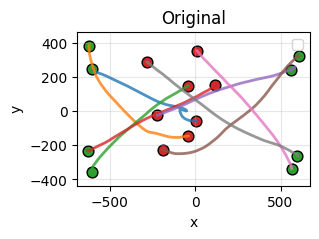

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_58441/2808851950.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


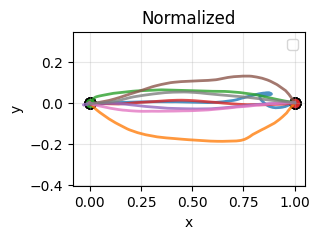

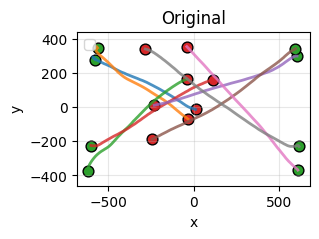

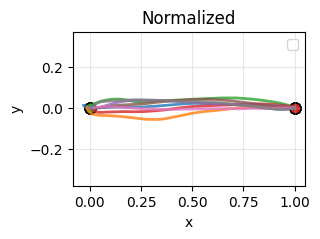

In [8]:
import ast
import numpy as np
import matplotlib.pyplot as plt

def _parse_path(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return []
    if isinstance(v, (list, tuple, np.ndarray)):
        return list(v)
    if isinstance(v, str):
        v = v.strip()
        return [] if not v else list(ast.literal_eval(v))
    return []

def plot_trajectories(
    df_selected,
    participant_id,
    session_no=None,
    block_no=None,
    extra_filter=None,   # e.g., {"trial_no": 3}
    max_traj=None,
    figsize=(3, 2),
):
    m = (df_selected["participant_id"] == participant_id)

    if session_no is not None:
        m &= (df_selected["session_no"] == session_no)

    if block_no is not None:
        m &= (df_selected["block_no"] == block_no)

    if extra_filter:
        for col, val in extra_filter.items():
            m &= (df_selected[col] == val)

    dff = df_selected.loc[m].copy()
    if max_traj is not None:
        dff = dff.head(max_traj)

    fig, ax = plt.subplots(figsize=figsize)

    first = True
    for _, row in dff.iterrows():
        path_pts = _parse_path(row["path"])

        # Trajectory
        if len(path_pts) >= 2:
            xs = [p[0] for p in path_pts]
            ys = [p[1] for p in path_pts]
            ax.plot(xs, ys, linewidth=2, alpha=0.8)

        # Start = first path point if available, else start_point_*
        if len(path_pts) >= 1:
            sx, sy = path_pts[0]
            ex, ey = path_pts[-1]  # End = last path point
        else:
            sx, sy = row["start_point_x"], row["start_point_y"]
            # If no path, treat "end" as target
            ex, ey = row["target_point_x"], row["target_point_y"]

        # Markers: start green circle, end red circle
        ax.scatter(sx, sy, s=60, marker="o", c="tab:green", edgecolors="black",
                   linewidths=1)
        ax.scatter(ex, ey, s=60, marker="o", c="tab:red", edgecolors="black",
                   linewidths=1)

        first = False

    ax.set_title(f"Original")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt

def plot_norm_trajectories(
    df_selected,
    participant_id,
    session_no=None,
    block_no=None,
    extra_filter=None,   # e.g., {"trial_no": 3}
    max_traj=None,
    figsize=(3, 2),
):
    m = (df_selected["participant_id"] == participant_id)

    if session_no is not None:
        m &= (df_selected["session_no"] == session_no)

    if block_no is not None:
        m &= (df_selected["block_no"] == block_no)

    if extra_filter:
        for col, val in extra_filter.items():
            m &= (df_selected[col] == val)

    dff = df_selected.loc[m]
    if max_traj is not None:
        dff = dff.head(max_traj)

    fig, ax = plt.subplots(figsize=figsize)

    first = True
    for _, row in dff.iterrows():
        traj = row["normalized_trajectory"]  # numpy array, shape (N, 3) as (x,y,t)

        if traj is None or (isinstance(traj, float) and np.isnan(traj)):
            continue

        traj = np.asarray(traj)
        if traj.ndim != 2 or traj.shape[0] == 0:
            continue

        xs = traj[:, 0]
        ys = traj[:, 1]

        ax.plot(xs, ys, linewidth=2, alpha=0.8)

        # start/end markers (green/red circles)
        ax.scatter(xs[0], ys[0], s=60, marker="o", c="tab:green", edgecolors="black",
                   linewidths=1)
        ax.scatter(xs[-1], ys[-1], s=60, marker="o", c="tab:red", edgecolors="black",
                   linewidths=1)

        first = False

    ax.set_title("Normalized")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# Examples:
# Example:
plot_trajectories(dataset, participant_id="MHEALTH141", session_no=1, block_no=1)
plot_norm_trajectories(dataset, participant_id="MHEALTH141", session_no=1, block_no=1)
plot_trajectories(dataset, participant_id="MHEALTH141", session_no=2, block_no=6)
plot_norm_trajectories(dataset, participant_id="MHEALTH141", session_no=2, block_no=6)



In [9]:
dataset['normalized_trajectory']

0       [[0.0, 0.0, 0.0], [-0.0005592437120531774, 0.0...
1       [[0.0, 0.0, 0.0], [-0.003341352071397844, -0.0...
2       [[0.0, 0.0, 0.0], [0.002455084734977379, 0.000...
3       [[0.0, 0.0, 0.0], [-0.0005081648358525669, 0.0...
4       [[0.0, 0.0, 0.0], [-0.002369049040289754, 0.00...
                              ...                        
4795    [[0.0, 0.0, 0.0], [0.00029198541477545376, 0.0...
4796    [[0.0, 0.0, 0.0], [-0.0010649907548600374, -0....
4797    [[0.0, 0.0, 0.0], [-0.000644242409386386, 7.71...
4798    [[0.0, 0.0, 0.0], [-0.0008787293748661917, -0....
4799    [[0.0, 0.0, 0.0], [0.0022669355065212883, 0.00...
Name: normalized_trajectory, Length: 4800, dtype: object

### Trajectory Embedding uisng saved model

In [13]:
%pip install -q -e "../../.."

import math
import json
import numpy as np
import sys
from pathlib import Path
import torch

# Ensure project/package paths are visible to the notebook kernel
_here = Path.cwd().resolve()
_candidate_roots = [_here] + list(_here.parents)
for _root in _candidate_roots:
    if (_root / "STCRL").exists():
        _root_str = str(_root)
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)

from STCRL.TransformerEncoder import STCRLTransformer  # ensure this import works

import math
import torch
def load_trajectory_model(model_path_no_ext="../saved_models/STCRL_transfer_learning/models/multi_loss_model"):
    """
    Loads STCRLTransformer using <path>_architecture.json + <path>.pt
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # from STCRL.TransformerEncoder import STCRLTransformer  # ensure this import works

    # Load architecture
    with open(model_path_no_ext + "_architecture.json", "r") as f:
        arch = json.load(f)

    # Build model exactly as trained
    model = STCRLTransformer(
        seq_len=arch["seq_len"],
        input_dim=arch["input_dim"],
        hidden_dim=arch["hidden_dim"],
        nhead=arch["nhead"],
        num_layers=arch["num_layers"],
        metadata_dim=arch.get("metadata_dim", 1),
    ).to(device)

    # Load checkpoint
    ckpt = torch.load(model_path_no_ext + ".pt", map_location=device)
    state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

    # Handle DataParallel: strip "module." if present
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=True)
    model.eval()

    print(f"Model successfully loaded from {model_path_no_ext}.pt")
    return model, device

def encode_single_trajectory(traj, model, device):
    """
    Encode a single trajectory using the trained model.
    
    Args:
        traj: Normalized trajectory as a numpy array with shape (512, 3)
        model: Loaded PyTorch model
        device: Device to run the encoding on
    
    Returns:
        Embedding as numpy array or None if encoding fails
    """
    model.eval()
    with torch.no_grad():
        if isinstance(traj, np.ndarray) and traj.shape == (512, 3):
            # Reshape to (batch_size, seq_len, features)
            traj_tensor = torch.FloatTensor(traj[:, :]).unsqueeze(0)  # Add batch dimension
            traj_tensor = traj_tensor.to(device)
            
            try:
                encoded, _, _ = model(traj_tensor)  # Assuming model returns (encoded, *, *)
                return encoded.cpu().numpy()[0]
            except Exception as e:
                print(f"Error encoding trajectory: {e}")
                return None
    return None

def add_trajectory_embeddings(df, model_path="saved_models/spatial_transfer_learning/multi_loss_model.pt", model_name="default"):
    """
    Add trajectory embeddings to the dataframe.
    
    Args:
        df: DataFrame with normalized_trajectory column
        model_path: Path to the saved model
        model_name: Name to use in the embedding column
    
    Returns:
        DataFrame with added trajectory embeddings
    """
    # Load model
    model, device = load_trajectory_model(model_path)
    if model is None:
        print("Failed to load model. Returning DataFrame without embeddings.")
        return df
    
    # Create column name for this model's embeddings
    column_name = f'trajectory_embedding_{model_name}'
    
    print(f"Adding embeddings for {model_name} model...")
    
    # Apply encoding row-wise
    embeddings = []
    total_rows = len(df)
    
    for idx, row in df.iterrows():
        # Get normalized trajectory
        if isinstance(row['normalized_trajectory'], str):
            try:
                traj = np.array(eval(row['normalized_trajectory']))
            except:
                print(f"Error parsing trajectory at row {idx}")
                embeddings.append(None)
                continue
        else:
            traj = row['normalized_trajectory']
        
        # Check if shape is as expected
        if traj.shape != (512, 3):
            print(f"Warning: Trajectory at row {idx} has shape {traj.shape}, expected (512, 3)")
            # Attempt to resample if possible
            if len(traj) > 0 and traj.shape[1] >= 3:
                # Resample to 512 points
                from scipy.interpolate import interp1d
                t_original = np.linspace(0, 1, len(traj))
                t_new = np.linspace(0, 1, 512)
                
                # Interpolate each dimension
                resampled = np.zeros((512, traj.shape[1]))
                for dim in range(traj.shape[1]):
                    f = interp1d(t_original, traj[:, dim])
                    resampled[:, dim] = f(t_new)
                
                traj = resampled
                print(f"Resampled to shape {traj.shape}")
            else:
                embeddings.append(None)
                continue
        
        # Encode the trajectory
        emb = encode_single_trajectory(traj, model, device)
        embeddings.append(emb)
        
        # Print progress
        if (idx + 1) % 100 == 0 or idx == total_rows - 1:
            print(f"Processed {idx+1}/{total_rows} trajectories")
    
    # Add embeddings to dataframe
    df[column_name] = embeddings
    
    # Print summary statistics
    n_encoded = sum(1 for emb in embeddings if emb is not None)
    embedding_dim = (
        embeddings[0].shape[0] if n_encoded > 0 and embeddings[0] is not None 
        else None
    )
    
    print(f"Number of encoded trajectories: {n_encoded}/{total_rows}")
    print(f"Embedding dimension: {embedding_dim}")
    
    return df

# Example usage
dataset = add_trajectory_embeddings(dataset, "../saved_models/STCRL_transfer_learning/models/multi_loss_model")

ERROR: file:///Users/mdraihanmia/Ubicomp/PMNL/R03%20Project does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.
Using device: cpu
Model successfully loaded from ../saved_models/STCRL_transfer_learning/models/multi_loss_model.pt
Adding embeddings for default model...
Processed 100/4800 trajectories
Processed 200/4800 trajectories
Processed 300/4800 trajectories
Processed 400/4800 trajectories
Processed 500/4800 trajectories
Processed 600/4800 trajectories
Processed 700/4800 trajectories
Processed 800/4800 trajectories
Processed 900/4800 trajectories
Processed 1000/4800 trajectories
Processed 1100/4800 trajectories
Processed 1200/4800 trajectories
Processed 1300/4800 trajectories
Processed 1400/4800 trajectories
Processed 1500/4800 trajectories
Processed 1600/4800 trajectories
Processed 1700/4800 trajectories
Processed 1800/4800 trajectories
Processed 1900/4800 trajectories
Processed 2000

In [ ]:
dataset

,participant_id,Age,day,trial_hand,session_no,planet,start_time,end_time,target_pos,planet_pos,...,actual_dist,rmsd,block_no,distances,normalized_trajectory,original_target_angle,rotation_angle,original_end_vector,is_success,trajectory_embedding_default
0,MHEALTH101,9,Day-1,Left,1,mercury,2025-02-28 13:23:43.2150,2025-02-28 13:24:00.4870,"[(48.2953931550412, -48.29539315504119)]","[(-597.625, 256.0)]",...,714.008992,12.277663,1,"[714.3732780872533, 715.0808266324252, 714.397...","[[0.0, 0.0, 0.0], [-0.0005592437120531774, 0.0...",-0.475935,0.475935,"[598.5000600814819, -308.5]",1,"[-1.8329861, -0.600562, -1.0607272, -0.6791401..."
1,MHEALTH101,9,Day-1,Left,1,venus,2025-02-28 13:24:00.4870,2025-02-28 13:24:04.9060,"[(6.856014457521658e-15, -111.9672131147541)]","[(-597.625, 341.3333435058594)]",...,750.091351,24.630668,1,"[747.5273075184907, 761.1705361391586, 764.192...","[[0.0, 0.0, 0.0], [-0.003341352071397844, -0.0...",-0.758482,0.758482,"[534.0000686645508, -506.0]",1,"[-1.6667144, -0.79311836, -1.2865267, 0.621947..."
2,MHEALTH101,9,Day-1,Left,1,earth,2025-02-28 13:24:04.9060,2025-02-28 13:24:07.6490,"[(9.840397221384027e-15, 160.7058823529412)]","[(-597.625, -341.3333435058594)]",...,780.512027,59.433053,1,"[806.5749941167204, 796.7861269535485, 795.197...","[[0.0, 0.0, 0.0], [0.002455084734977379, 0.000...",0.729849,-0.729849,"[579.0000686645508, 518.0]",1,"[-1.7034359, -0.8104837, -1.2743064, 0.5787799..."
3,MHEALTH101,9,Day-1,Left,1,mars,2025-02-28 13:24:07.6500,2025-02-28 13:24:09.9340,"[(155.79159082271354, 155.79159082271352)]","[(-597.625, -256.0)]",...,858.608685,29.660137,1,"[839.0129149927133, 841.7054893418715, 839.867...","[[0.0, 0.0, 0.0], [-0.0005081648358525669, 0.0...",0.524683,-0.524683,"[698.0000457763672, 404.0]",1,"[-1.6629314, -0.78201556, -1.2678684, 0.639328..."
4,MHEALTH101,9,Day-1,Left,1,jupiter,2025-02-28 13:24:09.9340,2025-02-28 13:24:17.5220,"[(-262.6923076923077, 3.217052937760162e-14)]","[(597.625, 256.0)]",...,897.597833,72.648872,1,"[858.2557798013395, 867.9322488352574, 868.411...","[[0.0, 0.0, 0.0], [-0.002369049040289754, 0.00...",-2.808568,2.808568,"[-782.0000610351562, -270.5]",1,"[-1.7314563, -0.7840375, -1.264138, 0.52487344..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,MHEALTH214,13,Day-2,Left,2,mars,2025-12-23 10:03:04.9490,2025-12-23 10:03:05.9080,"[(155.79159082271354, 155.79159082271352)]","[(-597.625, -256.0)]",...,858.608685,35.652826,6,"[865.0441459900183, 861.8406661505969, 860.131...","[[0.0, 0.0, 0.0], [0.00029198541477545376, 0.0...",0.483833,-0.483833,"[735.5000457763672, 386.5]",1,"[-1.4855839, -0.79667914, -1.3068805, 0.908424..."
4796,MHEALTH214,13,Day-2,Left,2,jupiter,2025-12-23 10:03:05.9080,2025-12-23 10:03:07.0170,"[(-262.6923076923077, 3.217052937760162e-14)]","[(597.625, 256.0)]",...,897.597833,60.707218,6,"[894.7048008655564, 903.349881602646, 911.1114...","[[0.0, 0.0, 0.0], [-0.0010649907548600374, -0....",-2.829746,2.829746,"[-820.5000762939453, -264.5]",1,"[-1.5181803, -0.80133766, -1.2931619, 0.891438..."
4797,MHEALTH214,13,Day-2,Left,2,saturn,2025-12-23 10:03:07.0170,2025-12-23 10:03:08.0340,"[(-229.97806264305336, -229.9780626430533)]","[(597.625, 341.3333435058594)]",...,1005.645838,61.242732,6,"[1037.5390106081704, 1044.8874391914658, 1051....","[[0.0, 0.0, 0.0], [-0.000644242409386386, 7.71...",-2.528536,2.528536,"[-819.5000762939453, -576.5]",1,"[-1.488328, -0.817228, -1.3135839, 0.9198725, ..."
4798,MHEALTH214,13,Day-2,Left,2,uranus,2025-12-23 10:03:08.0340,2025-12-23 10:03:09.0100,"[(2.389810753764692e-14, 390.2857142857143)]","[(597.625, -341.3333435058594)]",...,944.680944,32.734900,6,"[913.9449876590273, 922.1686079587926, 925.889...","[[0.0, 0.0, 0.0], [-0.0008787293748661917, -0....",2.278536,-2.278536,"[-557.0000686645508, 651.0]",1,"[-1.4916553, -0.7794105, -1.2842287, 0.9108102..."


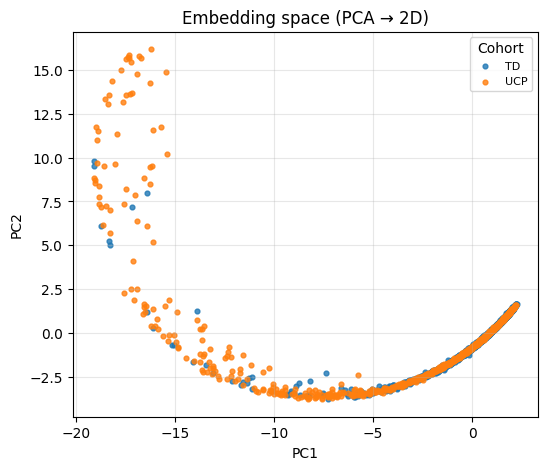

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings_pca(
    df,
    emb_col,
    color_col=None,          # e.g., "Cohort" or "participant_id"
    session_no=None,
    block_no=None,
    extra_filter=None,       # e.g., {"task_type": 1}
    figsize=(6, 5),
    alpha=0.8,
):
    dff = df.copy()

    # same filtering pattern
    m = pd.Series(True, index=dff.index)
    if session_no is not None:
        m &= (dff["session_no"] == session_no)
    if block_no is not None:
        m &= (dff["block_no"] == block_no)
    if extra_filter:
        for k, v in extra_filter.items():
            m &= (dff[k] == v)
    dff = dff.loc[m].copy()

    # build matrix Nx128
    emb = dff[emb_col].dropna()
    X = np.vstack([np.asarray(e).reshape(-1) for e in emb.values])
    dff = dff.loc[emb.index]

    if X.shape[1] != 128:
        raise ValueError(f"Expected 128-D embeddings, got {X.shape[1]}")

    Z = PCA(n_components=2, random_state=0).fit_transform(X)

    fig, ax = plt.subplots(figsize=figsize)

    if color_col is None:
        ax.scatter(Z[:, 0], Z[:, 1], s=12, alpha=alpha)
    else:
        colors = dff[color_col].astype(str).values
        for lab in pd.unique(colors):
            idx = colors == lab
            ax.scatter(Z[idx, 0], Z[idx, 1], s=12, alpha=alpha, label=lab)
        ax.legend(title=color_col, fontsize=8)

    ax.set_title("Embedding space (PCA → 2D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    plt.show()

# Example:
plot_embeddings_pca(dataset, emb_col="trajectory_embedding_default", color_col="Cohort")

### E-E Calulation

In [ ]:
dataset['task_type'] = 1
dataset.columns

Index(['participant_id', 'Age', 'day', 'trial_hand', 'session_no', 'planet',
       'start_time', 'end_time', 'target_pos', 'planet_pos', 'path',
       'time_string', 'time_diff_ms', 'completion_time', 'movement_dist',
       'trial_start_time', 'trial_no', 'target_point_x', 'target_point_y',
       'start_point_x', 'start_point_y', 'Cohort', 'actual_dist', 'rmsd',
       'block_no', 'distances', 'normalized_trajectory',
       'original_target_angle', 'rotation_angle', 'original_end_vector',
       'is_success', 'trajectory_embedding_default', 'task_type'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

def calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi',
                                             distance_metric='euclidean', window_size=8):
    """
    Calculate exploration and exploitation scores for sequential trials.
    Uses a rolling window approach to determine how much a participant is exploring vs exploiting.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing trajectory data with columns:
        - participant_id: to group trials by participant
        - task_type: to separate unimanual (0) and bimanual (1) tasks
        - day, block, trial_no: to order trials chronologically
        - embedding_column: trajectory embeddings
    
    embedding_column : str, default='trajectory_embedding_weighted_multi'
        Column name for the trajectory embeddings to use
    
    distance_metric : str, default='euclidean'
        Distance metric to use for measuring embedding similarities
    
    window_size : int, default=5
        Size of the rolling window to use for calculations
        
    Returns:
    --------
    pandas.DataFrame
        Original dataframe with additional columns:
        - exploration_score: higher values indicate more exploration
        - exploitation_score: higher values indicate more exploitation
    """
    
    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()
    
    # Initialize new columns for scores
    result_df['exploration_score'] = np.nan
    result_df['exploitation_score'] = np.nan
    result_df['novelty'] = np.nan
    result_df['avg_similarity_to_window'] = np.nan
    result_df['max_similarity_to_window'] = np.nan
    result_df['trial_seq'] = np.nan
    
    # Ensure embedding column is in numpy array format
    if isinstance(result_df[embedding_column].iloc[0], str):
        # Parse string embeddings properly
        result_df[embedding_column] = result_df[embedding_column].apply(
            lambda x: np.array([float(val) for val in x.strip('[]').split()]) if isinstance(x, str) else x
        )
    
    # Group by participant and task_type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically for this participant and task
        group_df = group_df.sort_values(by=['session_no', 'trial_no'])
        # group_df = group_df.reset_index(drop=True)
        
        # Create a sequence number for trials
        group_df['trial_seq'] = range(1, len(group_df) + 1)
        
        # Store sequence number in the result dataframe
        result_df.loc[group_df.index, 'trial_seq'] = group_df['trial_seq'].values
        
        # Handle missing embeddings by creating placeholder embeddings
        valid_embedding_indices = []
        valid_embeddings = []
        embedding_dim = None
        
        # First pass to identify valid embeddings and determine dimension
        for i, idx in enumerate(group_df.index):
            embedding = group_df.loc[idx, embedding_column]
            if embedding is not None and not (isinstance(embedding, float) and np.isnan(embedding)):
                if embedding_dim is None and hasattr(embedding, 'shape'):
                    embedding_dim = embedding.shape[0]
                valid_embedding_indices.append(i)
                valid_embeddings.append(embedding)
        
        # If we have no valid embeddings or couldn't determine dimension, skip this group
        if not valid_embeddings or embedding_dim is None:
            print(f"Warning: No valid embeddings for participant {participant_id}, task {task_type}")
            continue
        
        # Second pass to process distances only for valid embeddings
        if valid_embeddings:
            # Create array of valid embeddings
            valid_embeddings_array = np.vstack(valid_embeddings)
            
            # Calculate distances between valid embeddings
            valid_distances = cdist(valid_embeddings_array, valid_embeddings_array, metric=distance_metric)
            
            # Create a full distance matrix with NaNs for missing embeddings
            n_trials = len(group_df)
            all_distances = np.full((n_trials, n_trials), np.nan)
            
            # Fill in distances for valid embeddings
            for i, valid_i in enumerate(valid_embedding_indices):
                for j, valid_j in enumerate(valid_embedding_indices):
                    all_distances[valid_i, valid_j] = valid_distances[i, j]
            
            # Calculate scores for each trial in sequence
            for i, idx in enumerate(group_df.index):
                # For the first trial, set default values
                if i == 0:
                    result_df.loc[idx, 'exploration_score'] = 1.0
                    result_df.loc[idx, 'exploitation_score'] = 0.0
                    result_df.loc[idx, 'novelty'] = 1.0
                    result_df.loc[idx, 'avg_similarity_to_window'] = 0.0
                    result_df.loc[idx, 'max_similarity_to_window'] = 0.0
                    continue
                
                # Skip calculation if current trial has missing embedding
                if i not in valid_embedding_indices:
                    # Assign the mean or a default value for missing embeddings
                    if i > 0:
                        # Use the mean of previous valid scores as a fallback
                        valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                        valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                        
                        if len(valid_exploration_scores) > 0:
                            result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                        else:
                            result_df.loc[idx, 'exploration_score'] = 0.5  # Default
                            
                        if len(valid_exploitation_scores) > 0:
                            result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                        else:
                            result_df.loc[idx, 'exploitation_score'] = 0.5  # Default
                    
                    # Set other metrics to NaN or default values
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    continue
                
                # Filter out NaN values from distances to previous trials
                distances_to_previous = all_distances[i, :i]
                valid_previous_distances = distances_to_previous[~np.isnan(distances_to_previous)]
                
                if len(valid_previous_distances) > 0:
                    # Novelty: minimum distance to any previous trial
                    # Higher value means more different (more novel)
                    novelty = np.min(valid_previous_distances)
                    result_df.loc[idx, 'novelty'] = novelty
                    
                    # For window calculations, get start index
                    window_start = max(0, i - window_size)
                    
                    # Calculate distances to the window of previous trials
                    distances_to_window = all_distances[i, window_start:i]
                    valid_window_distances = distances_to_window[~np.isnan(distances_to_window)]
                    
                    if len(valid_window_distances) > 0:
                        # Convert distances to similarities (higher = more similar)
                        similarities_to_window = 1 / (1 + valid_window_distances)
                        
                        # Average similarity to window (measure of exploitation)
                        avg_similarity = np.mean(similarities_to_window)
                        result_df.loc[idx, 'avg_similarity_to_window'] = avg_similarity
                        
                        # Maximum similarity to any trial in window (measure of exploitation)
                        max_similarity = np.max(similarities_to_window)
                        result_df.loc[idx, 'max_similarity_to_window'] = max_similarity
                        
                        # Alternative exploration score: based on novelty (difference from previous trials)
                        # Normalize to keep early trials' scores high
                        trial_position_factor = np.exp(-0.01 * i)  # Decreases slowly with trial number
                        exploration_score = novelty * (0.7 + 0.3 * trial_position_factor)
                        
                        # Alternative exploitation score: based on similarity to window
                        # We use max similarity as the primary factor
                        exploitation_score = max_similarity
                        # print(participant_id, idx, exploration_score, exploitation_score)
                        result_df.loc[idx, 'exploration_score'] = exploration_score
                        result_df.loc[idx, 'exploitation_score'] = exploitation_score
                    else:
                        # No valid window distances
                        result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                        result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                        
                        # Use default values or interpolate from other trials
                        if i > 1:
                            # Use mean of previous scores
                            valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                            valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                            
                            if len(valid_exploration_scores) > 0:
                                result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                            else:
                                result_df.loc[idx, 'exploration_score'] = 0.5
                                
                            if len(valid_exploitation_scores) > 0:
                                result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                            else:
                                result_df.loc[idx, 'exploitation_score'] = 0.5
                else:
                    # No valid previous distances, set defaults
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'exploration_score'] = 0.5  # Default mid-point
                    result_df.loc[idx, 'exploitation_score'] = 0.5  # Default mid-point
    
    # Normalize scores to [0,1] range
    for score_col in ['exploration_score', 'exploitation_score']:
        min_val = result_df[score_col].min()
        max_val = result_df[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            result_df[score_col] = (result_df[score_col] - min_val) / (max_val - min_val)
    
    # Add task labels
    result_df['task_label'] = result_df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    return result_df

def calculate_exploration_exploitation_ratio(df, smoothing=0.01):
    """
    Calculate exploration/exploitation ratio for each trial.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration_score and exploitation_score columns
    
    smoothing : float, default=0.01
        Small value to avoid division by zero
    
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional column:
        - exploration_exploitation_ratio: ratio of exploration to exploitation
    """
    result_df = df.copy()
    
    # Calculate ratio (with smoothing to avoid division by zero)
    result_df['exploration_exploitation_ratio'] = (
        result_df['exploration_score'] / (result_df['exploitation_score'] + smoothing)
    )
    
    return result_df

def calculate_progression_metrics(df):
    """
    Calculate progression metrics based on sequential trial analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration and exploitation scores
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional progression metrics
    """
    result_df = df.copy()
    
    # Initialize columns
    result_df['learning_rate'] = np.nan
    result_df['strategy_stability'] = np.nan
    
    # Process each participant and task type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically 
        group_df = group_df.sort_values(by=['trial_seq'])
        
        # Get indices for this group
        indices = group_df.index
        
        # Skip if too few trials
        if len(indices) < 10:  # Need enough trials for meaningful metrics
            continue
            
        # Calculate rolling metrics
        window_size = min(5, len(indices) // 4)  # Adaptive window size
        
        for i in range(window_size, len(indices)):
            current_idx = indices[i]
            
            # Get window of previous trials
            window_indices = indices[i-window_size:i]
            window_df = group_df.loc[window_indices]
            
            # Calculate learning rate: change in performance over trials
            # Use whichever performance metrics are available
            if 'rmsd' in group_df.columns:
                # Negative learning rate because lower rmsd is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['rmsd'], 1)[0]
            elif 'completion_time' in group_df.columns:
                # Negative learning rate because lower time is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['completion_time'], 1)[0]
            else:
                # Default to exploitation trend if no performance metrics
                learning_rate = np.polyfit(window_df['trial_seq'], window_df['exploitation_score'], 1)[0]
            
            result_df.loc[current_idx, 'learning_rate'] = learning_rate
            
            # Strategy stability: consistency of exploration/exploitation ratio
            if 'exploration_exploitation_ratio' in window_df.columns:
                strategy_stability = 1 / (1 + window_df['exploration_exploitation_ratio'].std())
                result_df.loc[current_idx, 'strategy_stability'] = strategy_stability
    
    return result_df

In [ ]:
df_with_scores = calculate_exploration_exploitation_scores(dataset, embedding_column='trajectory_embedding_default')
df_with_ratio = calculate_exploration_exploitation_ratio(df_with_scores)
df_with_ratio_progress =calculate_progression_metrics(df_with_ratio)
df_with_ratio_progress

NameError: name 'calculate_exploration_exploitation_scores' is not defined

In [ ]:
df_with_ratio_progress.columns

Index(['participant_id', 'Age', 'day', 'trial_hand', 'session_no', 'planet',
       'start_time', 'end_time', 'target_pos', 'planet_pos', 'path',
       'time_string', 'time_diff_ms', 'completion_time', 'movement_dist',
       'trial_start_time', 'trial_no', 'target_point_x', 'target_point_y',
       'start_point_x', 'start_point_y', 'Cohort', 'actual_dist', 'rmsd',
       'block_no', 'distances', 'normalized_trajectory',
       'original_target_angle', 'rotation_angle', 'original_end_vector',
       'is_success', 'trajectory_embedding_default', 'task_type',
       'exploration_score', 'exploitation_score', 'novelty',
       'avg_similarity_to_window', 'max_similarity_to_window', 'trial_seq',
       'task_label', 'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')

In [ ]:
# df_with_ratio_progress.to_csv("../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories_ucpmp.csv", index=False)

Saved: ./plots/UCPMP/ee_ratio_td_ucp_learning.png


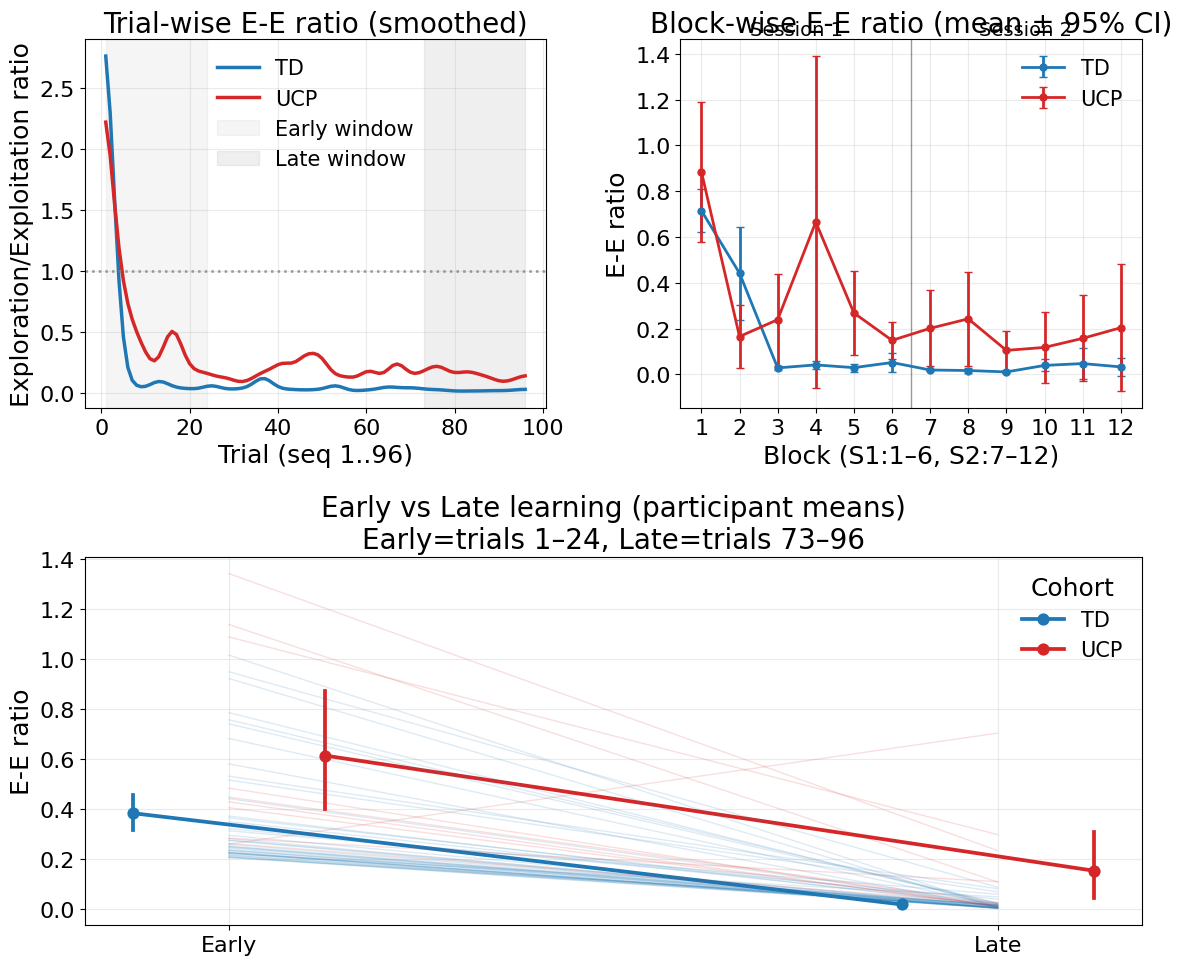

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec

def create_ee_ratio_visualizations_td_ucp(
    df_with_ratio_progress,
    save_dir=None,
    dpi=300,
    font_size=18,
    smooth_sigma=2,
    early_trials=24,     # first N trials (of 96)
    late_trials=24,      # last N trials (of 96)
    require_task_type=1  # reaching task
):
    """
    Visualize Exploration/Exploitation ratio for a dataset with:
      - Cohort in {"TD","UCP"}
      - single task (task_type=1)
      - 2 sessions x 6 blocks x 8 trials = 96 sequential trials per participant
      - trial_seq expected to be 1..96 per participant (if missing, we will compute it)

    Outputs:
      1) Trial-wise mean E-E ratio (TD vs UCP), smoothed
      2) Block-wise mean E-E ratio by session (session_no x block_no), TD vs UCP
      3) Early vs Late participant-level comparison (paired within participant)
      4) Simple stats (participant-level means; avoids trial-level pseudo-replication)
    """
    # --- matplotlib defaults ---
    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 2,
        "ytick.labelsize": font_size - 2,
        "legend.fontsize": font_size - 3,
        "figure.titlesize": font_size + 4,
    })

    df = df_with_ratio_progress.copy()

    # basic checks / cleanup
    needed = ["participant_id", "Cohort", "session_no", "block_no", "trial_no", "exploration_exploitation_ratio"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # keep only the reaching task if requested and present
    if require_task_type is not None and "task_type" in df.columns:
        df = df[df["task_type"] == require_task_type].copy()

    # sanitize ratio
    df["exploration_exploitation_ratio"] = pd.to_numeric(df["exploration_exploitation_ratio"], errors="coerce")
    df["exploration_exploitation_ratio"] = df["exploration_exploitation_ratio"].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["exploration_exploitation_ratio"]).copy()

    # ensure numeric ordering cols
    df["session_no"] = pd.to_numeric(df["session_no"], errors="coerce")
    df["block_no"] = pd.to_numeric(df["block_no"], errors="coerce")
    df["trial_no"] = pd.to_numeric(df["trial_no"], errors="coerce")

    # compute trial_seq (1..96) if missing or invalid
    if "trial_seq" not in df.columns or df["trial_seq"].isna().all():
        df = df.sort_values(["participant_id", "session_no", "block_no", "trial_no"], kind="mergesort")
        df["trial_seq"] = df.groupby("participant_id", sort=False).cumcount() + 1
    else:
        df["trial_seq"] = pd.to_numeric(df["trial_seq"], errors="coerce")

    # define Early/Late by global sequential trial index (per participant)
    max_seq = df.groupby("participant_id")["trial_seq"].max()
    # keep only participants with full 96 trials (optional but usually desired)
    keep_p = max_seq[max_seq >= 96].index
    df = df[df["participant_id"].isin(keep_p)].copy()

    df["phase"] = np.where(df["trial_seq"] <= early_trials, "Early",
                    np.where(df["trial_seq"] > (96 - late_trials), "Late", "Middle"))

    # --- FIGURE LAYOUT ---
    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

    ax_trial = plt.subplot(gs[0, 0])
    ax_block = plt.subplot(gs[0, 1])
    ax_phase = plt.subplot(gs[1, :])

    # ========== 1) Trial-wise ratio (TD vs UCP) ==========
    trial_g = (
        df.groupby(["Cohort", "trial_seq"])["exploration_exploitation_ratio"]
          .agg(["mean", "std", "count"])
          .reset_index()
          .sort_values("trial_seq")
    )
    trial_g["se"] = trial_g["std"] / np.sqrt(trial_g["count"].clip(lower=1))

    palette = {"TD": "#1f77b4", "UCP": "#d62728"}

    for cohort in ["TD", "UCP"]:
        d = trial_g[trial_g["Cohort"] == cohort]
        if d.empty:
            continue
        y = d["mean"].to_numpy()
        y_smooth = gaussian_filter1d(y, sigma=smooth_sigma) if len(y) >= 5 else y
        ax_trial.plot(d["trial_seq"], y_smooth, color=palette.get(cohort, None), linewidth=2.5, label=cohort)

    ax_trial.axhline(1.0, color="gray", linestyle=":", linewidth=1.8, alpha=0.8)
    ax_trial.axvspan(1, early_trials, color="gray", alpha=0.08, label="Early window" if True else None)
    ax_trial.axvspan(96 - late_trials + 1, 96, color="gray", alpha=0.12, label="Late window" if True else None)
    ax_trial.set_title("Trial-wise E-E ratio (smoothed)")
    ax_trial.set_xlabel("Trial (seq 1..96)")
    ax_trial.set_ylabel("Exploration/Exploitation ratio")
    ax_trial.grid(True, alpha=0.25)
    ax_trial.legend(frameon=False)

    # ========== 2) Block-wise by session (TD vs UCP) ==========
    # mean per (participant, session, block) first, then cohort mean => avoids overweighting participants with missing trials
    pb = (
        df.groupby(["participant_id", "Cohort", "session_no", "block_no"])["exploration_exploitation_ratio"]
          .mean()
          .reset_index()
    )
    sb = (
        pb.groupby(["Cohort", "session_no", "block_no"])["exploration_exploitation_ratio"]
          .agg(["mean", "std", "count"])
          .reset_index()
          .sort_values(["session_no", "block_no"])
    )
    sb["se"] = sb["std"] / np.sqrt(sb["count"].clip(lower=1))

    for cohort in ["TD", "UCP"]:
        d = sb[sb["Cohort"] == cohort]
        if d.empty:
            continue
        # map (session, block) to x positions 1..12 for plotting
        x = (d["session_no"] - 1) * 6 + d["block_no"]
        ax_block.errorbar(
            x, d["mean"], yerr=1.96 * d["se"],
            color=palette.get(cohort, None),
            linewidth=2, marker="o", markersize=5, capsize=3,
            label=cohort
        )

    ax_block.set_title("Block-wise E-E ratio (mean ± 95% CI)")
    ax_block.set_xlabel("Block (S1:1–6, S2:7–12)")
    ax_block.set_ylabel("E-E ratio")
    ax_block.set_xticks(list(range(1, 13)))
    ax_block.axvline(6.5, color="black", linewidth=1, alpha=0.4)
    ax_block.text(3.5, ax_block.get_ylim()[1] if ax_block.get_ylim()[1] != 1 else 1.02, "Session 1",
                  ha="center", va="bottom", fontsize=font_size-4)
    ax_block.text(9.5, ax_block.get_ylim()[1] if ax_block.get_ylim()[1] != 1 else 1.02, "Session 2",
                  ha="center", va="bottom", fontsize=font_size-4)
    ax_block.grid(True, alpha=0.25)
    ax_block.legend(frameon=False)

    # ========== 3) Early vs Late (participant-level; paired) ==========
    # participant-level mean in Early/Late windows
    ph = (
        df[df["phase"].isin(["Early", "Late"])]
        .groupby(["participant_id", "Cohort", "phase"])["exploration_exploitation_ratio"]
        .mean()
        .reset_index()
    )

    # show as pointplot + paired lines within participant
    sns.pointplot(
        data=ph, x="phase", y="exploration_exploitation_ratio", hue="Cohort",
        palette=palette, dodge=0.25, errorbar=("ci", 95), ax=ax_phase
    )

    # paired lines (light)
    for cohort, color in palette.items():
        d = ph[ph["Cohort"] == cohort].pivot(index="participant_id", columns="phase", values="exploration_exploitation_ratio")
        if {"Early", "Late"}.issubset(d.columns):
            for _, row in d.dropna(subset=["Early", "Late"]).iterrows():
                ax_phase.plot([0, 1], [row["Early"], row["Late"]], color=color, alpha=0.15, linewidth=1)

    ax_phase.set_title(f"Early vs Late learning (participant means)\nEarly=trials 1–{early_trials}, Late=trials {96-late_trials+1}–96")
    ax_phase.set_xlabel("")
    ax_phase.set_ylabel("E-E ratio")
    ax_phase.grid(True, alpha=0.25)
    ax_phase.legend(title="Cohort", frameon=False)

    plt.tight_layout()

    # --- STATS (participant-level) ---
    # Overall TD vs UCP (mean across all trials per participant)
    per_p = df.groupby(["participant_id", "Cohort"])["exploration_exploitation_ratio"].mean().reset_index()

    td = per_p[per_p["Cohort"] == "TD"]["exploration_exploitation_ratio"]
    ucp = per_p[per_p["Cohort"] == "UCP"]["exploration_exploitation_ratio"]
    overall_t = stats.ttest_ind(td, ucp, equal_var=False, nan_policy="omit") if (len(td) > 1 and len(ucp) > 1) else None

    # Early vs Late within cohort (paired t-test within participant)
    phase_wide = ph.pivot_table(index=["participant_id", "Cohort"], columns="phase", values="exploration_exploitation_ratio")
    phase_stats = {}
    for cohort in ["TD", "UCP"]:
        d = phase_wide.xs(cohort, level="Cohort", drop_level=False) if cohort in phase_wide.index.get_level_values("Cohort") else None
        if d is None or d.empty or not {"Early", "Late"}.issubset(d.columns):
            phase_stats[cohort] = None
            continue
        x = d["Early"].to_numpy()
        y = d["Late"].to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)
        phase_stats[cohort] = stats.ttest_rel(x[ok], y[ok]) if ok.sum() > 1 else None

    # Early TD vs UCP and Late TD vs UCP (between-subject)
    early_p = ph[ph["phase"] == "Early"].groupby(["participant_id", "Cohort"])["exploration_exploitation_ratio"].mean().reset_index()
    late_p  = ph[ph["phase"] == "Late"].groupby(["participant_id", "Cohort"])["exploration_exploitation_ratio"].mean().reset_index()

    early_t = None
    late_t = None
    if set(early_p["Cohort"]) >= {"TD", "UCP"}:
        early_t = stats.ttest_ind(
            early_p[early_p["Cohort"] == "TD"]["exploration_exploitation_ratio"],
            early_p[early_p["Cohort"] == "UCP"]["exploration_exploitation_ratio"],
            equal_var=False, nan_policy="omit"
        )
    if set(late_p["Cohort"]) >= {"TD", "UCP"}:
        late_t = stats.ttest_ind(
            late_p[late_p["Cohort"] == "TD"]["exploration_exploitation_ratio"],
            late_p[late_p["Cohort"] == "UCP"]["exploration_exploitation_ratio"],
            equal_var=False, nan_policy="omit"
        )

    stats_out = {
        "n_participants": per_p.groupby("Cohort")["participant_id"].nunique().to_dict(),
        "overall_td_vs_ucp_ttest": overall_t,
        "early_td_vs_ucp_ttest": early_t,
        "late_td_vs_ucp_ttest": late_t,
        "early_vs_late_within_cohort_paired_ttest": phase_stats,
    }

    # save
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, "ee_ratio_td_ucp_learning.png")
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved: {out_path}")

    # reset defaults
    plt.rcdefaults()

    return {"figure": fig, "stats": stats_out, "df_used": df}


# Usage:
results = create_ee_ratio_visualizations_td_ucp(df_with_ratio_progress, save_dir="./plots/UCPMP/")


In [ ]:
print(results["stats"])

{'n_participants': {'TD': 40, 'UCP': 10}, 'overall_td_vs_ucp_ttest': TtestResult(statistic=-2.559566711166508, pvalue=0.0291492350891662, df=9.647783778084921), 'early_td_vs_ucp_ttest': TtestResult(statistic=-1.710252300779461, pvalue=0.11650174653492971, df=10.520683990706164), 'late_td_vs_ucp_ttest': TtestResult(statistic=-1.9546279345737463, pvalue=0.0821981499267199, df=9.043347169722033), 'early_vs_late_within_cohort_paired_ttest': {'TD': TtestResult(statistic=10.099199484816863, pvalue=1.933438096466427e-12, df=39), 'UCP': TtestResult(statistic=3.247117843856477, pvalue=0.010043580498892158, df=9)}}
